Methodologies for an end-to-end data analyics projects

1. Problem statement/ objectives
2. Data collection
3. Data investigation
4. Data cleaning and transformation
5. Exploratory data analysis and visualization
6. Data storytelling
7. Recommendations
8. Executive summary
9. Limitations
10. Report / communication

## 🏢 Company Overview
Vintage Couture is a fashion retail brand specializing in curated vintage clothing collections. The company caters to diverse customer demographics across multiple regions, offering products through various sales channels. With a growing customer base, Vintage Couture aims to leverage data-driven insights to optimize revenue, understand customer behavior, and enhance overall business performance.

❗ Problem Statement

While Vintage Couture has accumulated a rich dataset of sales transactions, customer demographics, and regional performance, the company lacks a structured analysis to uncover actionable insights. Key challenges include:

- Measuring total revenue and identifying peak performance periods.

- Understanding customer demographics (age, gender, region) and their contribution to revenue.

- Comparing sales channels and payment methods to evaluate efficiency.

- Pinpointing top-performing states and regions to guide targeted marketing.

- Visualizing monthly revenue trends to detect growth opportunities.

- Developing a dashboard that integrates slicers and visualizations for interactive reporting.

Without these insights, Vintage Couture risks missing opportunities to optimize sales strategies, improve customer engagement, and strengthen regional market penetration.

In [25]:
# import all neccessary libraries
import numpy as np
import pandas as pd

# for visuals
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
!pip install openpyxl

In [27]:
# import the dataset
file_path = r'C:\Users\user\gomycodePYTHON\Vintage_Clothing_Sales_Data (2).xlsx'
df1 = pd.read_excel(file_path, sheet_name='Vintage Clothing Data')
df1.head()

,Order ID,Customer Id,Date,Status,Payment ID,Channel,Product Category,Size,Qty,Amount,Location Id,B2B
0,171-1029312-3038738,CS-1029312,2022-12-04,Delivered,2,Store,Denim,XXL,1,376,LC01,False
1,405-2183842-2225946,CS-2183842,2022-12-04,Delivered,3,Online,Suit,L,1,1449,LC02,False
2,171-1641533-8921966,CS-1641533,2022-12-04,Delivered,3,Store,Suit,S,1,453,LC03,False
3,404-7490807-6300351,CS-7490807,2022-12-04,Delivered,1,Online,Suit,M,1,729,LC04,False
4,403-9293516-4577154,CS-9293516,2022-12-04,Delivered,2,Store,Denim,XXL,1,544,LC02,False


In [28]:
df2 = pd.read_excel(file_path, sheet_name='Payment')
df2.head()

,Payment ID,Payment Type
0,1,Cash
1,2,Card
2,3,Transfer


In [29]:
df3 = pd.read_excel(file_path, sheet_name=2)
df3.head()

,Location Id,State,Region
0,LC01,Abia,South-East
1,LC02,Adamawa,North-East
2,LC03,Akwa Ibom,South-South
3,LC04,Anambra,South-East
4,LC05,Bauchi,North-East


In [30]:
df4 = pd.read_excel(file_path, sheet_name=3)
df4.head()

,Customer Id,Gender,Age
0,CS-1029312,Women,44
1,CS-2183842,Women,29
2,CS-1641533,Women,67
3,CS-7490807,Women,20
4,CS-9293516,Women,62


In [31]:
# strip the leading and trailing spaces from the column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()
df4.columns = df4.columns.str.strip()

In [33]:
# merge the dataframes on the common key
df_merged = df1.merge(df2, on="Payment ID", how="left")
df_merged = df_merged.merge(df3, on="Location Id", how="left")
df_merged = df_merged.merge(df4, on="Customer Id", how="left")

# check the first 5 rows of the merged dataframe
print("\nMerged Data:") 
print(df_merged.head())


Merged Data:
              Order ID Customer Id       Date     Status  Payment ID Channel  \
0  171-1029312-3038738  CS-1029312 2022-12-04  Delivered           2   Store   
1  405-2183842-2225946  CS-2183842 2022-12-04  Delivered           3  Online   
2  171-1641533-8921966  CS-1641533 2022-12-04  Delivered           3   Store   
3  404-7490807-6300351  CS-7490807 2022-12-04  Delivered           1  Online   
4  403-9293516-4577154  CS-9293516 2022-12-04  Delivered           2   Store   

  Product Category Size  Qty  Amount Location Id    B2B Payment Type  \
0            Denim  XXL    1     376        LC01  False         Card   
1             Suit    L    1    1449        LC02  False     Transfer   
2             Suit    S    1     453        LC03  False     Transfer   
3             Suit    M    1     729        LC04  False         Cash   
4            Denim  XXL    1     544        LC02  False         Card   

       State       Region Gender  Age  
0       Abia   South-East  Women

In [34]:
# export the merged dataframe to a new excel file
df_merged.to_excel('vintage_clothing_merged.xlsx', index=False)

In [36]:
# check for missing values
print("\nMissing Values:")
print(df_merged.isnull().sum()) # isnull() and isna() are the same , you can either of them to check for missing values


Missing Values:
Order ID            0
Customer Id         0
Date                0
Status              0
Payment ID          0
Channel             0
Product Category    0
Size                0
Qty                 0
Amount              0
Location Id         0
B2B                 0
Payment Type        0
State               0
Region              0
Gender              0
Age                 0
dtype: int64


In [37]:
# age group from the age column in the merged dataframe
def age_group(age): 
    if age <=30:
        return 'Young Adult'
    elif age <=40:
        return 'Adult'
    elif age <=49:
        return 'Middle-Aged Adult'
    else:
        return 'Senior'
    
df_merged['Age Group'] = df_merged['Age'].apply(age_group)

#check the frst 5 rows of the merged dataframe with age group
print("\nMerged Data with Age Group:")
print(df_merged.head())


Merged Data with Age Group:
              Order ID Customer Id       Date     Status  Payment ID Channel  \
0  171-1029312-3038738  CS-1029312 2022-12-04  Delivered           2   Store   
1  405-2183842-2225946  CS-2183842 2022-12-04  Delivered           3  Online   
2  171-1641533-8921966  CS-1641533 2022-12-04  Delivered           3   Store   
3  404-7490807-6300351  CS-7490807 2022-12-04  Delivered           1  Online   
4  403-9293516-4577154  CS-9293516 2022-12-04  Delivered           2   Store   

  Product Category Size  Qty  Amount Location Id    B2B Payment Type  \
0            Denim  XXL    1     376        LC01  False         Card   
1             Suit    L    1    1449        LC02  False     Transfer   
2             Suit    S    1     453        LC03  False     Transfer   
3             Suit    M    1     729        LC04  False         Cash   
4            Denim  XXL    1     544        LC02  False         Card   

       State       Region Gender  Age          Age Group 

In [ ]:
# drop unnecessary columns from the merged dataframe, like  

In [38]:
# info of merged dataframe
print("\nMerged DataFrame Info:")
print(df_merged.info())


Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26407 entries, 0 to 26406
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          26407 non-null  object        
 1   Customer Id       26407 non-null  object        
 2   Date              26407 non-null  datetime64[ns]
 3   Status            26407 non-null  object        
 4   Payment ID        26407 non-null  int64         
 5   Channel           26407 non-null  object        
 6   Product Category  26407 non-null  object        
 7   Size              26407 non-null  object        
 8   Qty               26407 non-null  int64         
 9   Amount            26407 non-null  int64         
 10  Location Id       26407 non-null  object        
 11  B2B               26407 non-null  bool          
 12  Payment Type      26407 non-null  object        
 13  State             26407 non-null  object        
 14

In [39]:
# check for missing values
print("\nMissing Values in Merged DataFrame:")
print(df_merged.isna().sum()) # isnull() and isna() are the same, you can use either of them to check for missing values


Missing Values in Merged DataFrame:
Order ID            0
Customer Id         0
Date                0
Status              0
Payment ID          0
Channel             0
Product Category    0
Size                0
Qty                 0
Amount              0
Location Id         0
B2B                 0
Payment Type        0
State               0
Region              0
Gender              0
Age                 0
Age Group           0
dtype: int64


In [40]:
# age group from the age column in the merged dataframe
def age_group(age):
    if age <= 30:
        return 'Young Adult'
    elif age <= 40:
        return 'Adult'
    elif age <= 49:
        return 'Middle-Aged Adult'
    else:
        return 'Senior'
    
df_merged['Age Group'] = df_merged['Age'].apply(age_group)

# check the first 5 rows of the merged dataframe with age group
print("\nMerged Data with Age Group:")
print(df_merged.head())


Merged Data with Age Group:
              Order ID Customer Id       Date     Status  Payment ID Channel  \
0  171-1029312-3038738  CS-1029312 2022-12-04  Delivered           2   Store   
1  405-2183842-2225946  CS-2183842 2022-12-04  Delivered           3  Online   
2  171-1641533-8921966  CS-1641533 2022-12-04  Delivered           3   Store   
3  404-7490807-6300351  CS-7490807 2022-12-04  Delivered           1  Online   
4  403-9293516-4577154  CS-9293516 2022-12-04  Delivered           2   Store   

  Product Category Size  Qty  Amount Location Id    B2B Payment Type  \
0            Denim  XXL    1     376        LC01  False         Card   
1             Suit    L    1    1449        LC02  False     Transfer   
2             Suit    S    1     453        LC03  False     Transfer   
3             Suit    M    1     729        LC04  False         Cash   
4            Denim  XXL    1     544        LC02  False         Card   

       State       Region Gender  Age          Age Group 

In [41]:
# drop unnecessary columns from the merged datafram, like B2B, and Size
df_merged.drop(columns=['B2B', 'Size'], inplace=True)

# check the first 5 rows of the merged dataframe after dropping unnecessary columns
print("\nMerged Data after dropping unnecessary columns:")
print(df_merged.head())


Merged Data after dropping unnecessary columns:
              Order ID Customer Id       Date     Status  Payment ID Channel  \
0  171-1029312-3038738  CS-1029312 2022-12-04  Delivered           2   Store   
1  405-2183842-2225946  CS-2183842 2022-12-04  Delivered           3  Online   
2  171-1641533-8921966  CS-1641533 2022-12-04  Delivered           3   Store   
3  404-7490807-6300351  CS-7490807 2022-12-04  Delivered           1  Online   
4  403-9293516-4577154  CS-9293516 2022-12-04  Delivered           2   Store   

  Product Category  Qty  Amount Location Id Payment Type      State  \
0            Denim    1     376        LC01         Card       Abia   
1             Suit    1    1449        LC02     Transfer    Adamawa   
2             Suit    1     453        LC03     Transfer  Akwa Ibom   
3             Suit    1     729        LC04         Cash    Anambra   
4            Denim    1     544        LC02         Card    Adamawa   

        Region Gender  Age          Age Gro

In [42]:
# Data Validation and Cleaning
# check for duplicates in the merged dataframe
print("\nNumber of duplicate rows in Merged DataFrame:")
print(df_merged.duplicated().sum())


Number of duplicate rows in Merged DataFrame:
0


In [43]:
# # To drop duplicates, you can use the drop_duplicates() method
# df_merged.drop_duplicates(inplace=True)
# print("\nMerged Data after dropping duplicates:")
# print(df_merged.head())

In [44]:
# select only the numeric columns
numeric_cols = df_merged.select_dtypes(include='number')
print(numeric_cols)

       Payment ID  Qty  Amount  Age
0               2    1     376   44
1               3    1    1449   29
2               3    1     453   67
3               1    1     729   20
4               2    1     544   62
...           ...  ...     ...  ...
26402           1    1     385   30
26403           2    1     495   60
26404           2    1    1115   29
26405           3    1     399   46
26406           2    1     791   36

[26407 rows x 4 columns]


In [45]:
# select only the categorical columns
categorical_cols = df_merged.select_dtypes(include='object')
print(categorical_cols)

                  Order ID Customer Id     Status Channel Product Category  \
0      171-1029312-3038738  CS-1029312  Delivered   Store            Denim   
1      405-2183842-2225946  CS-2183842  Delivered  Online             Suit   
2      171-1641533-8921966  CS-1641533  Delivered   Store             Suit   
3      404-7490807-6300351  CS-7490807  Delivered  Online             Suit   
4      403-9293516-4577154  CS-9293516  Delivered   Store            Denim   
...                    ...         ...        ...     ...              ...   
26402  405-7447678-6283558  CS-7447678  Delivered   Store            Denim   
26403  405-4837393-8997115  CS-4837393  Delivered  Online            Denim   
26404  408-3572295-5992330  CS-3572295  Delivered  Online             Suit   
26405  405-1423498-9705162  CS-1423498  Delivered  Online            Denim   
26406  408-4694875-8249153  CS-4694875  Delivered  Online      Sport Wears   

      Location Id Payment Type      State       Region Gender  

In [46]:
# loop through the categorical columns and print the unique values in each column using value_counts() method
for col in categorical_cols.columns:
    print(f"\nUnique values in column '{col}':")
    print(categorical_cols[col].value_counts())


Unique values in column 'Order ID':
Order ID
171-1029312-3038738    1
171-5408286-4795549    1
403-4921300-5141900    1
406-1608096-9223518    1
171-5511473-8029153    1
                      ..
407-8620606-1798713    1
406-7339406-4201119    1
406-4177841-2321943    1
406-8337504-6926762    1
408-4694875-8249153    1
Name: count, Length: 26407, dtype: int64

Unique values in column 'Customer Id':
Customer Id
CS-7935467    2
CS-5107060    2
CS-4515268    2
CS-4357489    2
CS-4804006    2
             ..
CS-402793     1
CS-8472414    1
CS-2945733    1
CS-9937747    1
CS-4694875    1
Name: count, Length: 26378, dtype: int64

Unique values in column 'Status':
Status
Delivered    24351
Returned       932
Cancelled      704
Refunded       420
Name: count, dtype: int64

Unique values in column 'Channel':
Channel
Online    16714
Store      8619
Vendor     1074
Name: count, dtype: int64

Unique values in column 'Product Category':
Product Category
Suit                     10860
Denim         

In [47]:
# Type of Exploratory Data Analysis (EDA) to perform on the merged dataframe
# Univariate Analysis: Analyze the distribution of individual variables 
# Bivariate Analysis: Analyze the relationship between two variables
# Multivariate Analysis: Analyze the relationship between multiple variables

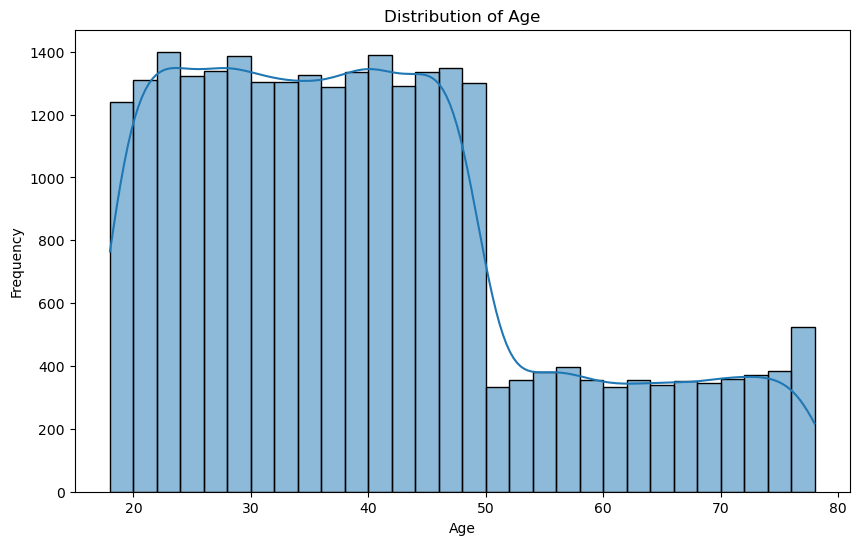

In [48]:
# Univariate Analysis and Visualization
# Distribution of Age with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

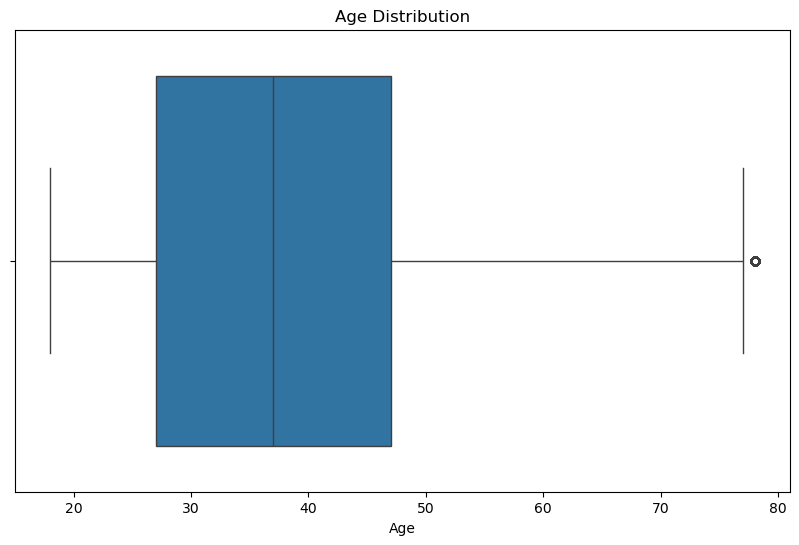

In [50]:
#Age distribution using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_merged['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

The boxplot shows that most customers fall between ages 28 and 48, with a median around 38 years.
Younger adults (18-30) and middle-aged adults (41-49) dominate the core customer base, while seniors are fewer but present. A small outlier near age 78 highlights that vintage couture attracts a wide age range, though revenue strategies should focus on the central age group.

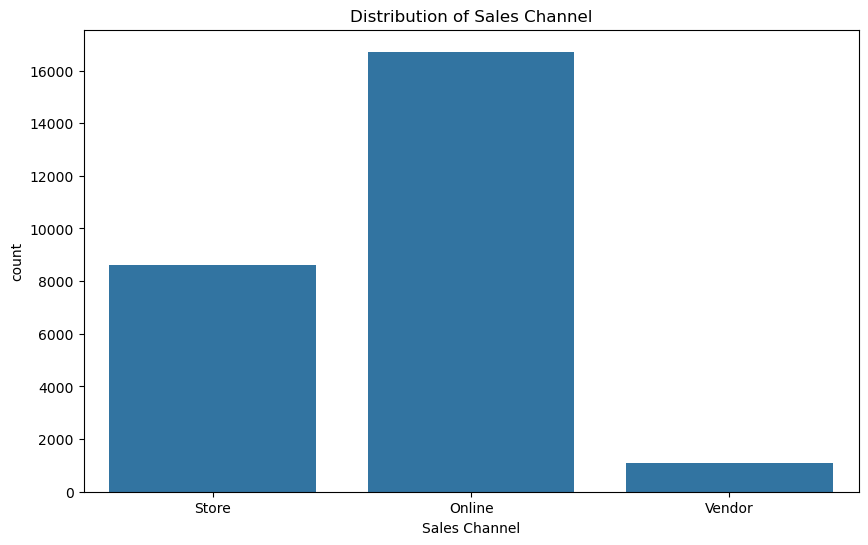

In [51]:
# chanel distribution using countplot
plt.figure(figsize=(10, 6))
sns.countplot(x=df_merged['Channel'])
plt.title('Distribution of Sales Channel')
plt.xlabel('Sales Channel')
plt.show()  

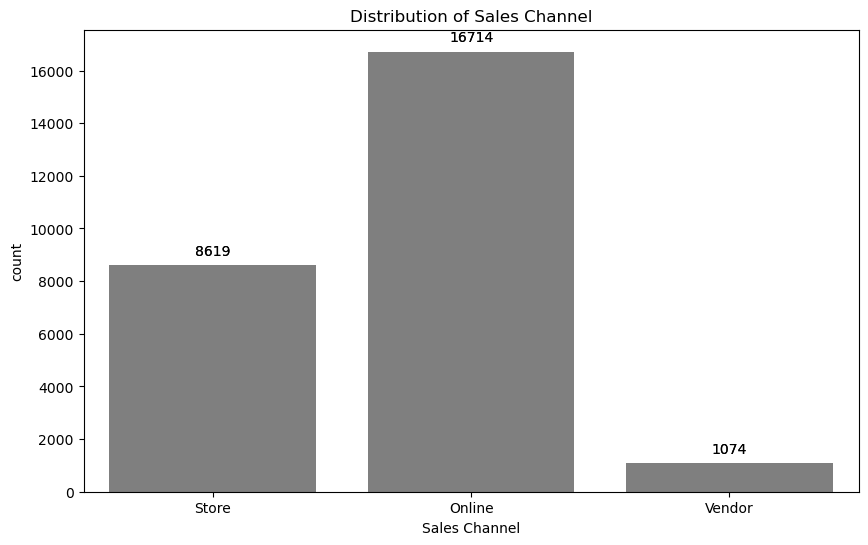

In [52]:
# chanel distribution using countplot with data labels
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=df_merged['Channel'])

for p in sns.countplot(x=df_merged['Channel']).patches:
    sns.countplot(x=df_merged['Channel']).annotate(format(p.get_height(), '.0f'), 
                                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                                        ha='center', va='center', 
                                        xytext=(0, 10), textcoords='offset points')
plt.title('Distribution of Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('count')
plt.show()

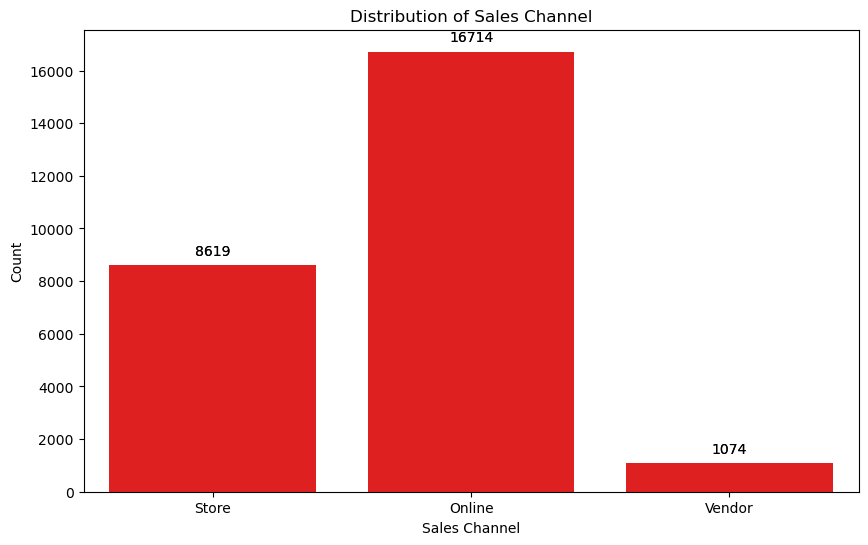

In [ ]:
# channel ditribution using countplot with data labels #i just used a different color for the bars to make the data labels more visible
plt.figure(figsize=(10, 6))
sns.countplot(x=df_merged['Channel'])

for p in sns.countplot(x=df_merged['Channel'], color='red').patches:
    sns.countplot(x=df_merged['Channel'], color='red').annotate(format(p.get_height(), '.0f'), 
                                                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                                                  ha = 'center', va = 'center', 
                                                  xytext = (0, 10), textcoords = 'offset points')
plt.title('Distribution of Sales Channel') 
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.show()

Online sales dominate vintage coutures performance, accounting for the larges share of transaction compared to store and vendor channels. store sales remain strong but seondary, while vendor sales contribute minimally. this highlights the importance of strenghtening digital strategies while optimizing physicalnstore presence

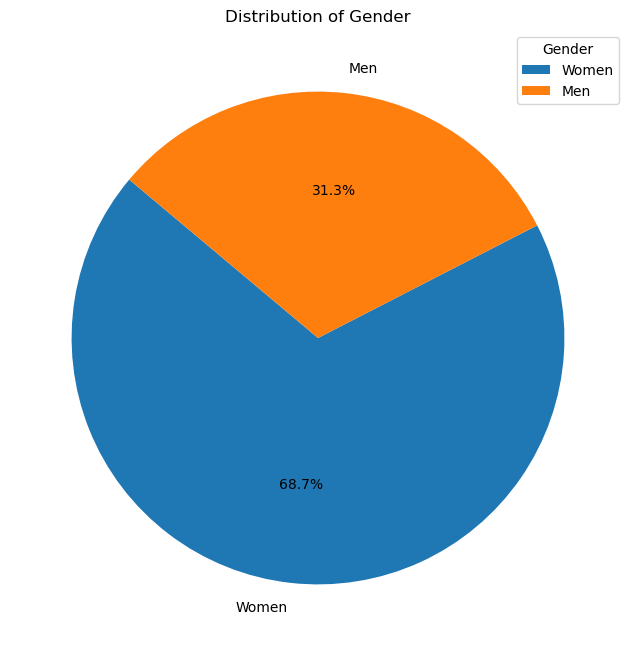

In [55]:
# Gender distribution using pie chart with data labels and legend
plt.figure(figsize=(8, 8))
plt.pie(df_merged['Gender'].value_counts(), labels=df_merged['Gender'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Gender')
plt.legend(title='Gender')
plt.show()

Women make up the majority of Vintage couture's customer base, representing 68% of sales, while men account for
31.3%. This indicates that the brand resonates ore strongly with female shoppers, suggesting opportunities to
further tailor product offerings and marketing strategies towards women while exploring ways to grow engagement among men.

In [56]:
# Bivariate Analysis
df_merged.head()

,Order ID,Customer Id,Date,Status,Payment ID,Channel,Product Category,Qty,Amount,Location Id,Payment Type,State,Region,Gender,Age,Age Group
0,171-1029312-3038738,CS-1029312,2022-12-04,Delivered,2,Store,Denim,1,376,LC01,Card,Abia,South-East,Women,44,Middle-Aged Adult
1,405-2183842-2225946,CS-2183842,2022-12-04,Delivered,3,Online,Suit,1,1449,LC02,Transfer,Adamawa,North-East,Women,29,Young Adult
2,171-1641533-8921966,CS-1641533,2022-12-04,Delivered,3,Store,Suit,1,453,LC03,Transfer,Akwa Ibom,South-South,Women,67,Senior
3,404-7490807-6300351,CS-7490807,2022-12-04,Delivered,1,Online,Suit,1,729,LC04,Cash,Anambra,South-East,Women,20,Young Adult
4,403-9293516-4577154,CS-9293516,2022-12-04,Delivered,2,Store,Denim,1,544,LC02,Card,Adamawa,North-East,Women,62,Senior


In [57]:
# create a sales column
df_merged['Sales'] = df_merged['Qty'] * df_merged['Amount']
df_merged.head()

,Order ID,Customer Id,Date,Status,Payment ID,Channel,Product Category,Qty,Amount,Location Id,Payment Type,State,Region,Gender,Age,Age Group,Sales
0,171-1029312-3038738,CS-1029312,2022-12-04,Delivered,2,Store,Denim,1,376,LC01,Card,Abia,South-East,Women,44,Middle-Aged Adult,376
1,405-2183842-2225946,CS-2183842,2022-12-04,Delivered,3,Online,Suit,1,1449,LC02,Transfer,Adamawa,North-East,Women,29,Young Adult,1449
2,171-1641533-8921966,CS-1641533,2022-12-04,Delivered,3,Store,Suit,1,453,LC03,Transfer,Akwa Ibom,South-South,Women,67,Senior,453
3,404-7490807-6300351,CS-7490807,2022-12-04,Delivered,1,Online,Suit,1,729,LC04,Cash,Anambra,South-East,Women,20,Young Adult,729
4,403-9293516-4577154,CS-9293516,2022-12-04,Delivered,2,Store,Denim,1,544,LC02,Card,Adamawa,North-East,Women,62,Senior,544


In [59]:
# Month with the highest total sales
df_merged['Month'] = df_merged['Date'].dt.month
monthly_sales = df_merged.groupby('Month')['Sales'].sum().reset_index()
print(monthly_sales)

    Month    Sales
0       1  1541169
1       2  1615756
2       3  1697987
3       4  1606999
4       5  1578587
5       6  1525967
6       7  1515422
7       8  1578973
8       9  1457528
9      10  1454507
10     11  1443971
11     12  1397109


In [63]:
# create a month name using the mapping stategy
df_merged['Month Name'] = df_merged['Month'].map({1: 'January',
                                                  2: 'Feruary',
                                                  3: 'March',
                                                  4: 'April',
                                                  5: 'May',
                                                  6: 'June',
                                                  7: 'July',
                                                  8: 'August',
                                                  9: 'September',
                                                  10: 'October',
                                                  11: 'November',
                                                  12: 'December'})
df_merged.head()











,Order ID,Customer Id,Date,Status,Payment ID,Channel,Product Category,Qty,Amount,Location Id,Payment Type,State,Region,Gender,Age,Age Group,Sales,Month,Month Name
0,171-1029312-3038738,CS-1029312,2022-12-04,Delivered,2,Store,Denim,1,376,LC01,Card,Abia,South-East,Women,44,Middle-Aged Adult,376,12,December
1,405-2183842-2225946,CS-2183842,2022-12-04,Delivered,3,Online,Suit,1,1449,LC02,Transfer,Adamawa,North-East,Women,29,Young Adult,1449,12,December
2,171-1641533-8921966,CS-1641533,2022-12-04,Delivered,3,Store,Suit,1,453,LC03,Transfer,Akwa Ibom,South-South,Women,67,Senior,453,12,December
3,404-7490807-6300351,CS-7490807,2022-12-04,Delivered,1,Online,Suit,1,729,LC04,Cash,Anambra,South-East,Women,20,Young Adult,729,12,December
4,403-9293516-4577154,CS-9293516,2022-12-04,Delivered,2,Store,Denim,1,544,LC02,Card,Adamawa,North-East,Women,62,Senior,544,12,December


In [65]:
monthly_sales = df_merged.groupby(['Month Name', 'Month'])['Sales'].sum().reset_index().sort_values(by='Month', ascending=True)
print(monthly_sales)

   Month Name  Month    Sales
4     January      1  1541169
3     Feruary      2  1615756
7       March      3  1697987
0       April      4  1606999
8         May      5  1578587
6        June      6  1525967
5        July      7  1515422
1      August      8  1578973
11  September      9  1457528
10    October     10  1454507
9    November     11  1443971
2    December     12  1397109


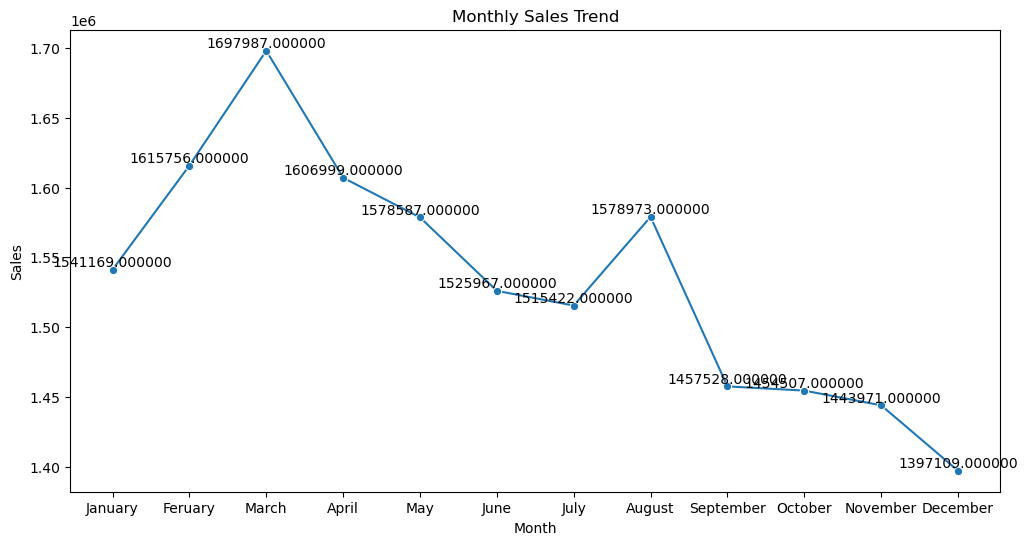

In [70]:
# visualize the monthly sales using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month Name', y='Sales', data=monthly_sales, marker='o')

#Add data labels to the line plot
for x, y in zip(monthly_sales['Month Name'], monthly_sales['Sales']):
    plt.text(x, y, f'{y:0f}', ha='center', va='bottom')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

Sales peaked in March at 1,697,987 making it the highest revenue month of the year. After this peak, sales gradually declined, reaching their lowest point in december at 1,397,109. The  overall trend shows strong early-year performance followed by a steady downward trajectory toward year-end

In [71]:
# Age group with the highest revenue contribution
age_group_sales = df_merged.groupby('Age Group')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
print(age_group_sales)

           Age Group    Sales
3        Young Adult  5997141
0              Adult  4600546
1  Middle-Aged Adult  4184156
2             Senior  3632132


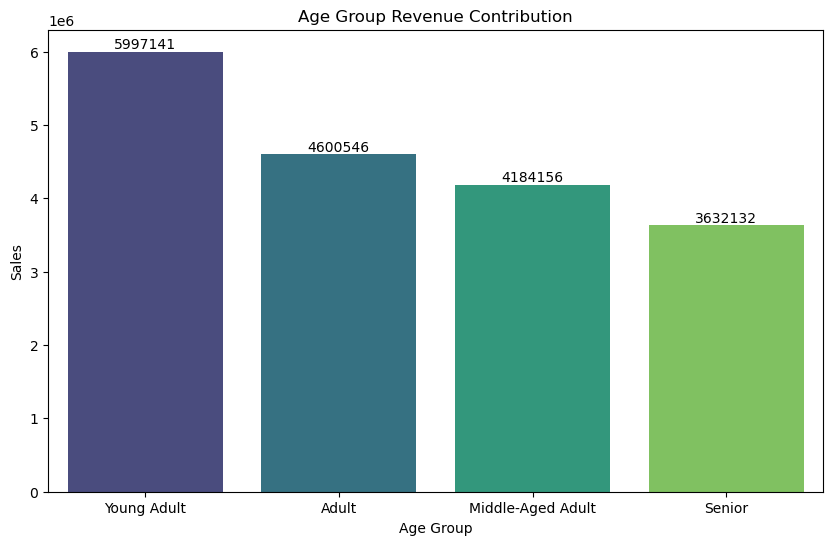

In [72]:
# Age group with the highest revenue contribution using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Sales', data=age_group_sales, palette='viridis', hue='Age Group')

# Add data labels to the bar plot
ax = plt.gca()
for i, (index, row) in enumerate(age_group_sales.iterrows()):
    ax.text(i, row['Sales'], f'{row["Sales"]:.0f}', ha='center', va='bottom')

plt.title('Age Group Revenue Contribution')
plt.xlabel('Age Group')
plt.ylabel('Sales')
plt.show()

Young Adults are the strongest revenue drivers, contributing **$5,997,141**, followed by Adults at **4,600, 546** and Middle-Aged Adults at **4,184,156**. Seniors generate the least, with **B,632,132**, showing that
younger customers are the most profitable segment. This highlights the importance of tailoring marketing and product strategies toward the younger demographic while still engaging older groups to expand growth.